# 🏭 海螺水泥(600585) 股价分析

**B 路线第一个项目:用 pandas 读真实股价数据 + matplotlib 画折线图**

- 数据:2024-08-30 ~ 2026-08-28,共 483 个交易日,前复权日K
- 数据来源:腾讯财经公开接口(免费、无需注册)
- 本笔记本要做三件事:
  1. 用 pandas 读 CSV、看懂数据结构
  2. 画一张收盘价折线图
  3. 加上移动平均线,画出「专业感」

👉 按顺序从上到下运行每个代码格子(点中格子后按 **Shift + Enter**)

In [1]:
# 第 1 步:导入工具库
import pandas as pd                    # 数据分析之王,处理表格数据
import matplotlib.pyplot as plt        # 画图之王,把数据变成图

# 让 matplotlib 支持中文(重要!不设置的话,图里中文会变成小方块)
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS", "Heiti SC", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False   # 让负号正常显示

print("库导入成功! ✅")

库导入成功! ✅


In [2]:
# 第 2 步:读取 CSV 数据文件
df = pd.read_csv("海螺水泥_600585_日K.csv")

print("表格形状(行数 × 列数):", df.shape)
print("共", len(df), "个交易日")
df.head()   # 看前 5 行

表格形状(行数 × 列数): (483, 7)
共 483 个交易日


,date,open,close,high,low,volume,pct_change
0,2024-08-30,19.04,19.36,19.90,18.86,18842100.0,NaN
1,2024-09-02,19.31,19.30,19.56,19.09,12556900.0,-0.31
2,2024-09-03,19.32,19.16,19.42,19.02,11615800.0,-0.73
3,2024-09-04,19.04,18.98,19.18,18.78,10217400.0,-0.94
4,2024-09-05,18.98,19.38,19.40,18.93,11745300.0,2.11


In [3]:
# 第 3 步:快速认识每一列是什么意思
#   date       日期
#   open       开盘价(当天第一笔成交价)
#   close      收盘价(当天最后一笔成交价) ← 我们重点看它
#   high       最高价
#   low        最低价
#   volume     成交量(股)
#   pct_change 当日涨跌幅(%)

print("数据基本信息:")
df.info()

print("\n最近 5 天行情:")
df.tail()

print("\n整体统计:")
df.describe().round(2)

数据基本信息:
<class 'pandas.DataFrame'>
RangeIndex: 483 entries, 0 to 482
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        483 non-null    str    
 1   open        483 non-null    float64
 2   close       483 non-null    float64
 3   high        483 non-null    float64
 4   low         483 non-null    float64
 5   volume      483 non-null    float64
 6   pct_change  482 non-null    float64
dtypes: float64(6), str(1)
memory usage: 31.3 KB

最近 5 天行情:

整体统计:


,open,close,high,low,volume,pct_change
count,483.00,483.00,483.00,483.00,4.830000e+02,482.00
mean,21.88,21.87,22.14,21.63,2.847070e+07,0.00
std,2.18,2.16,2.22,2.12,2.238780e+07,1.80
min,16.30,16.34,16.55,16.17,6.380100e+06,-8.71
25%,21.04,21.10,21.32,20.90,1.644470e+07,-0.92
50%,22.37,22.36,22.57,22.17,2.356590e+07,-0.13
75%,23.30,23.31,23.60,23.06,3.272220e+07,0.68
max,27.19,26.32,27.19,25.47,2.706173e+08,10.42


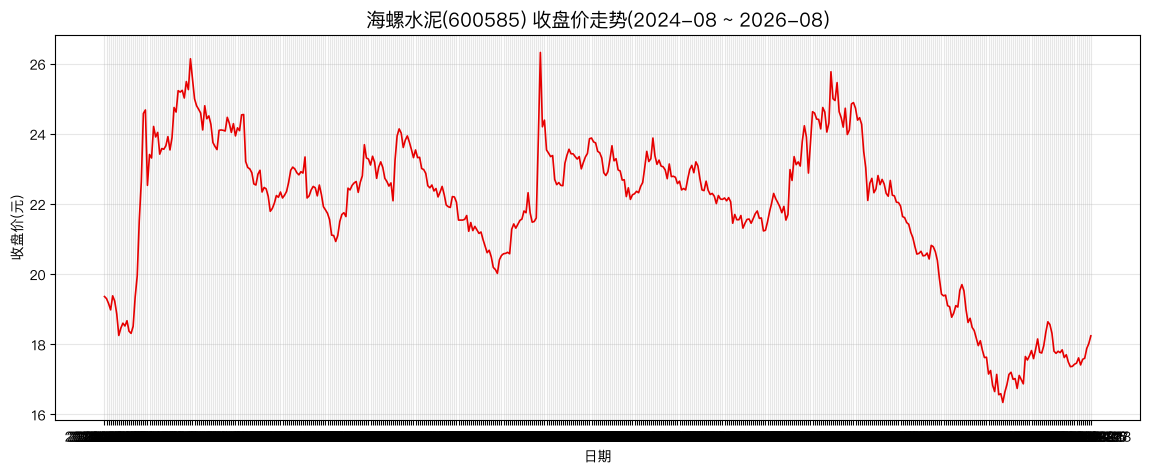

图已画出!🎉 这就是你的第一张股价折线图


In [4]:
# 第 4 步:画第一张图——收盘价折线图
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["close"], color="#e60000", linewidth=1.2)

plt.title("海螺水泥(600585) 收盘价走势(2024-08 ~ 2026-08)", fontsize=14)
plt.xlabel("日期")
plt.ylabel("收盘价(元)")
plt.grid(alpha=0.3)
plt.show()

print("图已画出!🎉 这就是你的第一张股价折线图")

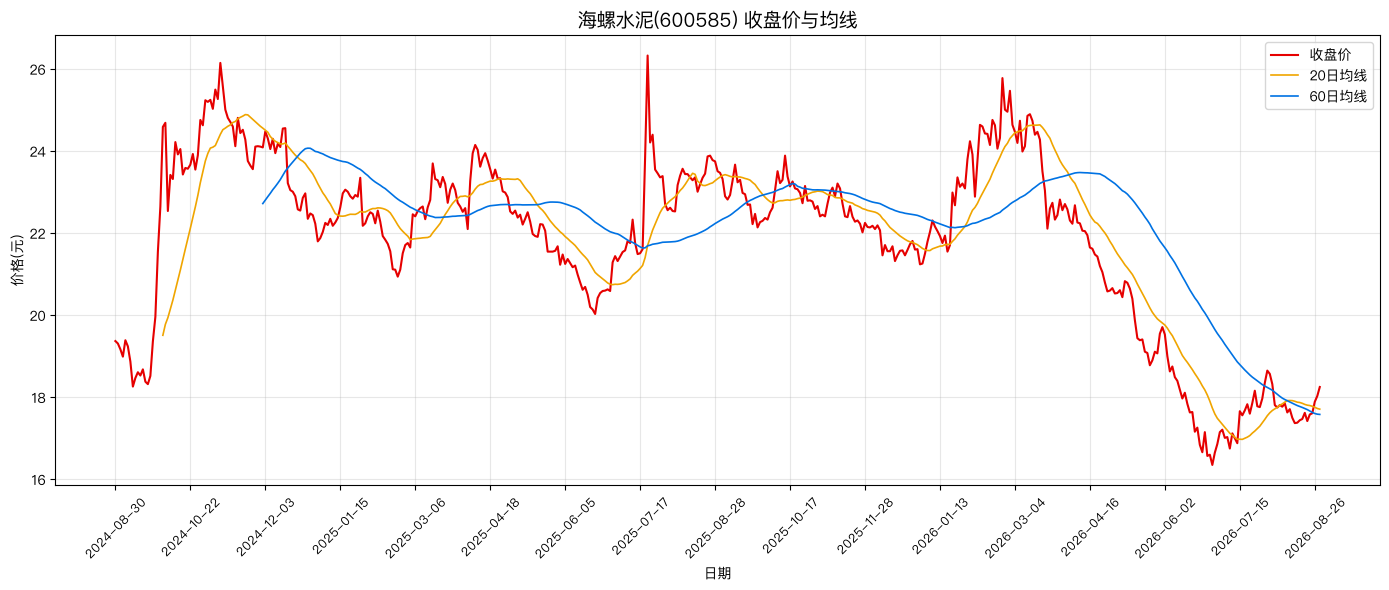

均线图完成!红色=每日收盘价,橙色=20日均线,蓝色=60日均线


In [5]:
# 第 5 步:加移动平均线,让趋势更清楚
# 移动平均线 = 最近 N 天的平均收盘价,能抹平每天的"毛刺",看出大趋势

df["MA20"] = df["close"].rolling(window=20).mean()   # 20日均线(约1个月)
df["MA60"] = df["close"].rolling(window=60).mean()   # 60日均线(约1个季度)

plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["close"], label="收盘价", linewidth=1.5, color="#e60000")
plt.plot(df["date"], df["MA20"], label="20日均线", linewidth=1.2, color="#f0a500")
plt.plot(df["date"], df["MA60"], label="60日均线", linewidth=1.2, color="#0072e3")

plt.title("海螺水泥(600585) 收盘价与均线", fontsize=14)
plt.xlabel("日期")
plt.ylabel("价格(元)")
plt.legend()
plt.grid(alpha=0.3)

# 日期太多会挤成一团,每隔 30 个交易日显示一个日期标签
ticks = range(0, len(df), 30)
plt.xticks(ticks, df["date"].iloc[ticks], rotation=45, fontsize=9)

plt.tight_layout()
plt.show()

print("均线图完成!红色=每日收盘价,橙色=20日均线,蓝色=60日均线")

## ✏️ 小练习(动手时间!)

**题目 1(简单)**:把第 5 步的代码复制到下面,改成只画**最近 3 个月**(约 60 个交易日)的收盘价。
提示:先用 `df.tail(60)` 取出最近 60 行,再画。

**题目 2(中等)**:用 pandas 找出这两年:
- 涨得**最凶**的一天(涨幅最大)?
- 跌得**最狠**的一天(跌幅最大)?
提示:试试 `df["pct_change"].max()`、`.min()`,再用 `df.loc[df["pct_change"].idxmax()]` 取出那一天。

**题目 3(综合)**:假设 2024 年 8 月 30 日你买了 **100 股**海螺水泥,持有到今天:
- 一共花了多少钱?(用当天开盘价算)
- 现在值多少钱?(用最新收盘价算)
- 赚了还是亏了?多少元?多少 %?

想不出来可以看下面两个参考答案(都带注释)。

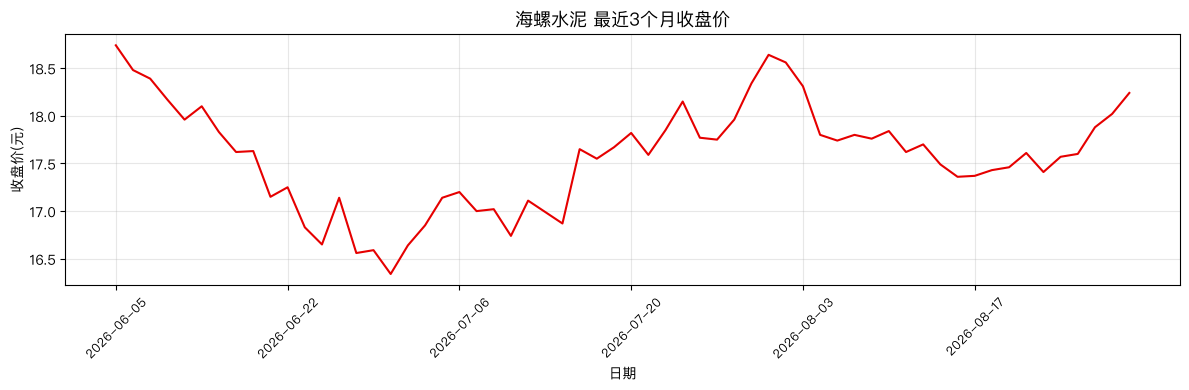

In [6]:
# ✏️ 练习1参考答案:只画最近 3 个月
recent = df.tail(60)   # 取最近 60 个交易日(约3个月)

plt.figure(figsize=(12, 4))
plt.plot(recent["date"], recent["close"], color="#e60000", linewidth=1.5)

plt.title("海螺水泥 最近3个月收盘价", fontsize=13)
plt.xlabel("日期")
plt.ylabel("收盘价(元)")
ticks = range(0, len(recent), 10)
plt.xticks(ticks, recent["date"].iloc[ticks], rotation=45, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ✏️ 练习2参考答案:找出涨跌幅最大的一天
best  = df.loc[df["pct_change"].idxmax()]   # 涨最多的日子
worst = df.loc[df["pct_change"].idxmin()]   # 跌最多的日子
print("📈 涨幅最大的一天:", best["date"], "收盘", best["close"], "元,涨幅", best["pct_change"], "%")
print("📉 跌幅最大的一天:", worst["date"], "收盘", worst["close"], "元,跌幅", worst["pct_change"], "%")

# ✏️ 练习3参考答案:100股持有两年的盈亏
buy_price  = df["open"].iloc[0]     # 2024-08-30 的开盘价
sell_price = df["close"].iloc[-1]   # 最新收盘价
cost   = buy_price * 100             # 买入成本
value  = sell_price * 100            # 现在市值
profit = value - cost                # 盈亏金额
print(f"\n💸 2024-08-30 开盘价 {buy_price} 元,买 100 股花了 {cost:.2f} 元")
print(f"💎 今天收盘 {sell_price} 元,100 股值 {value:.2f} 元")
print(f"📊 盈亏: {profit:+.2f} 元 ({(profit/cost*100):+.2f}%)")

📈 涨幅最大的一天: 2025-07-21 收盘 23.85 元,涨幅 10.42 %
📉 跌幅最大的一天: 2024-10-09 收盘 22.53 元,跌幅 -8.71 %

💸 2024-08-30 开盘价 19.04 元,买 100 股花了 1904.00 元
💎 今天收盘 18.24 元,100 股值 1824.00 元
📊 盈亏: -80.00 元 (-4.20%)
